# Trail Analysis & Visualization Tool – Bilingual Guide / Анализ на трекове и визуализация Двуезично ръководство

In [ ]:
import xml.etree.ElementTree as ET
import folium
import matplotlib.pyplot as plt
import numpy as np
import requests
from geopy.distance import geodesic
import os
import pathlib
import csv
from IPython.display import display, IFrame
from datetime import datetime, timedelta
# За PNG експорт (по избор)
try:
    from selenium import webdriver
    from selenium.webdriver.chrome.options import Options
    from selenium.webdriver.chrome.service import Service
    from webdriver_manager.chrome import ChromeDriverManager
    SELENIUM_AVAILABLE = True
except ImportError:
    SELENIUM_AVAILABLE = False
    print("Selenium не е инсталиран – PNG експортът ще бъде пропуснат. Инсталирайте с: pip install selenium webdriver-manager")

In [ ]:
# ================================================================
# РЪЧНО ЗАДАВАНЕ НА ВРЪХ (използва се ако OSM не го открие)
# ================================================================
MANUAL_PEAK_NAME = "връх Ком"       # Променете или оставете None
MANUAL_PEAK_ELEVATION = 2016        # Променете или оставете None
# ================================================================

## 🇧🇬 Описание на български

Ноутбукът обработва KML файл (например от GPS устройство или туристическо приложение) и генерира пълен анализ на прехода, включително интерактивни карти, анимации и табло с резултати.

### 🔍 1. Парсиране на KML
- Чете KML файла и извлича:
  - **Маршрути** (LineString) – поредици от (дължина, ширина, надморска височина).
  - **Точки** (Point) – допълнителни обекти, често с имена.

### ⛰ 2. Допълване на липсващи височини
- Ако дадена точка няма височина, тя се извлича от **Open-Elevation API**.
- При липса на връзка се задава `0.0`.

### 🏔 3. Определяне на върха
- Намира най-високата точка от всички тракове.
- Запитва **OpenStreetMap (Overpass API)** за най-близкия официален връх (`natural=peak`) в радиус 1000 m.
- Ако OSM не върне резултат, може да зададете ръчно `MANUAL_PEAK_NAME` и `MANUAL_PEAK_ELEVATION`.

### 📊 4. Статистики на маршрута
- За всеки маршрут се изчислява:
  - **Разстояние** (в km) чрез геодезични формули.
  - **Прогнозен брой крачки** (`1312 крачки/km`).
  - **Време за преход** при скорост `4 km/h` (променлива).
  - **Начална височина** и **височина на върха** (от официалния връх или от данните).

### 📝 5. Обновяване на CSV файл
- Всички статистики се записват в `trek_stats/trek_statistics.csv`.
- Дублиращи се записи (еднакъв връх, начална/крайна височина, разстояние и време) не се добавят повторно.
- Новодобавените редове се номерират автоматично.

### 🗺 6. Интерактивна карта (OpenTopoMap)
- Карта с топографски слой, създадена с Folium.
- Маршрутите са оцветени в червено.
- Поставени са маркери:
  - 🟢 Начало (зелена икона) с начална височина.
  - ⚫ Край (черен флаг).
  - 🔴 Официален връх (тъмночервена планина) с име и височина.
  - 🔵 Именовани точки от KML.
- Картата се запазва като HTML файл.

### 📈 7. Профил на надморската височина
- Статична графика (matplotlib) – височина спрямо изминато разстояние.
- Началото, върхът и краят са обозначени.
- Запазва се като PNG изображение.

### 🎬 8. Анимация в стил Relive
- Анимирана карта, която “прелита” по първия маршрут.
- Динамичен HUD показва:
  - Текуща височина
  - Изминато разстояние
  - Изминало време (според скоростта)
  - Прогрес бар и процент.
- Има бутони за пауза / пускане / повторение.
- Запазва се като самостоятелен HTML файл.

### 🖥 9. Табло (Dashboard)
- Самостоятелна HTML страница, обединяваща картата, профила и анимацията.
- Всички числови статистики са изведени в списък.
- Може да се отвори във всеки браузер.

### 📸 10. Експорт като PNG (по желание)
- Ако са инсталирани `selenium` и `webdriver-manager`, таблото се запазва и като PNG снимка.

### ⚙️ Настройки
- `kml_file` – име на вашия KML файл.
- `MANUAL_PEAK_NAME` / `MANUAL_PEAK_ELEVATION` – ръчно задаване на върха.
- `SPEED_KMH` – скорост (по подразбиране 4.0).
- `STEPS_PER_KM` – крачки на километър (1312).
- `duration_sec` – продължителност на анимацията (12).

## 🇬🇧 English Description

This notebook processes a KML file (e.g. from a GPS device or hiking app) and produces a complete analysis of your mountain hike, including interactive maps, animations, and a dashboard.

### 🔍 1. KML Parsing
- Reads a `.kml` file and extracts:
  - **Tracks** (LineString elements) – sequences of (longitude, latitude, elevation).
  - **Points** (Point elements) – additional markers, often with names.

### ⛰ 2. Elevation Completion
- If any track point lacks elevation data, it is fetched from the **Open-Elevation API**.
- Falls back to `0.0` if the API is unavailable.

### 🏔 3. Peak Identification
- Finds the highest elevation among all tracks.
- Queries **OpenStreetMap (Overpass API)** for the nearest official `natural=peak` within 1000 m.
- If no peak is found, you can manually set `MANUAL_PEAK_NAME` and `MANUAL_PEAK_ELEVATION` at the top of the notebook.

### 📊 4. Route Statistics
- For each track, the following are calculated:
  - **Distance** (km) using geodesic calculations.
  - **Estimated steps** (using `STEPS_PER_KM = 1312`).
  - **Travel time** at a constant speed of `4 km/h` (adjustable).
  - **Start elevation** and **peak elevation** (official or from data).

### 📝 5. CSV Statistics Update
- All statistics are saved to `trek_stats/trek_statistics.csv`.
- Duplicate entries (identical peak, start/end elevation, distance, and time) are **not** added twice.
- New entries are automatically numbered.

### 🗺 6. Interactive Map (OpenTopoMap)
- A Folium map with topographic tiles.
- Tracks are drawn as red polylines.
- Markers show:
  - 🟢 Start (green play icon) with starting elevation.
  - ⚫ End (black flag icon).
  - 🔴 Official peak (dark red mountain icon) with name and height.
  - 🔵 Named points from the KML file.
- The map is saved as an HTML file.

### 📈 7. Elevation Profile
- A static plot (matplotlib) of elevation vs. distance.
- Start, peak, and end points are highlighted.
- Saved as a PNG image.

### 🎬 8. Relive‑Style Animation
- An animated map that “flies” along the first track.
- A live HUD shows:
  - Current elevation
  - Distance covered
  - Elapsed time (based on walking speed)
  - Progress bar and percentage.
- Play / Pause / Repeat buttons are included.
- The animation is saved as a standalone HTML file.

### 🖥 9. Dashboard HTML
- A self‑contained HTML page combining the interactive map, elevation profile, and animation.
- All statistics are displayed in a clean list.
- Can be shared and opened in any browser.

### 📸 10. Optional PNG Export
- If `selenium` and `webdriver-manager` are installed, the dashboard is also saved as a PNG screenshot.

### ⚙️ Customisation
- `kml_file` – name of your KML file.
- `MANUAL_PEAK_NAME` / `MANUAL_PEAK_ELEVATION` – manual override for the peak.
- `SPEED_KMH` – walking speed (default 4.0).
- `STEPS_PER_KM` – steps per kilometre (default 1312).
- `duration_sec` – animation length (default 12).

Запазване на резултатите от прехода в папка: kom/
Намерени са 1 маршрута и 0 точки
Извличане на липсващи данни за надморска височина...
OSM не откри връх – използвам ръчно зададените стойности.
Максимална височина по трака: 1997 м
Официален връх: връх Ком – 2016 м
Маршрут: 5.54 км | 7261 крачки | 1 ч 23 мин | Старт: 1534 м | Връх: 2016 м
Маршрутът вече съществува в trek_stats\trek_statistics.csv. Пропускане на повторен запис.
Картата е запазена в kom\kom_map.html


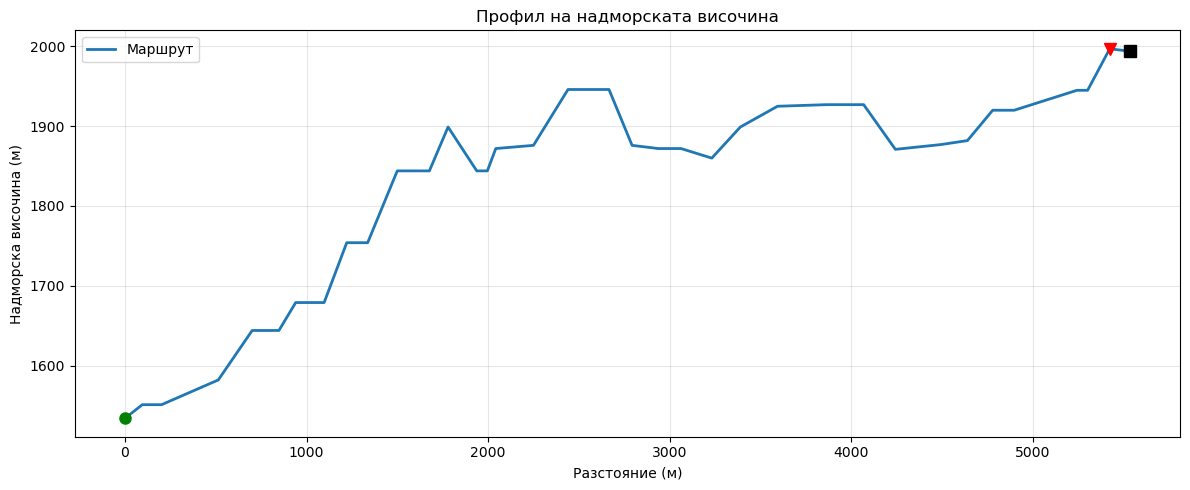

Профилът е запазен в kom\kom_profile.png
Создаване на анимирана карта (12 секунди)...
Анимацията е запазена в kom\kom_animation.html


Таблото е запазено в kom\kom_dashboard.html
PNG изображението е запазено в kom\kom_dashboard.png


In [29]:
# ------------------------------------------------------------
# 1. Парсиране на KML
# ------------------------------------------------------------
def parse_kml(filepath):
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    tree = ET.parse(filepath)
    root = tree.getroot()
    tracks, points = [], []
    for pm in root.findall('.//kml:Placemark', ns):
        for ls in pm.findall('.//kml:LineString', ns):
            coord_elem = ls.find('kml:coordinates', ns)
            if coord_elem is None or not coord_elem.text: continue
            pts = []
            for block in coord_elem.text.strip().split():
                parts = block.split(',')
                if len(parts) >= 2:
                    lon, lat = float(parts[0]), float(parts[1])
                    ele = float(parts[2]) if len(parts) >= 3 and parts[2].strip() != '' else None
                    pts.append((lon, lat, ele))
            if pts: tracks.append(pts)
        for pt in pm.findall('.//kml:Point', ns):
            coord_elem = pt.find('kml:coordinates', ns)
            if coord_elem is None or not coord_elem.text: continue
            parts = coord_elem.text.strip().split(',')
            if len(parts) >= 2:
                lon, lat = float(parts[0]), float(parts[1])
                name_elem = pm.find('kml:name', ns)
                name = name_elem.text.strip() if name_elem is not None and name_elem.text else ''
                points.append((lon, lat, name))
    return tracks, points

# ------------------------------------------------------------
# 2. Извличане на надморска височина (ако липсва в KML)
# ------------------------------------------------------------
def fetch_elevations(coords):
    url = "https://api.open-elevation.com/api/v1/lookup"
    payload = {"locations": [{"latitude": lat, "longitude": lon} for lon, lat in coords]}
    try:
        r = requests.post(url, json=payload, timeout=10)
        if r.status_code == 200:
            return [res['elevation'] for res in r.json()['results']]
    except: pass
    return [0.0]*len(coords)

# ------------------------------------------------------------
# 3. Намиране на най-близкия официален връх чрез OpenStreetMap
# ------------------------------------------------------------
def find_nearest_peak(lat, lon, radius=1000):
    overpass_url = "http://overpass-api.de/api/interpreter"
    query = f"""
    [out:json];
    (
      node["natural"="peak"](around:{radius},{lat},{lon});
    );
    out body;
    """
    try:
        resp = requests.post(overpass_url, data=query, timeout=15)
        if resp.status_code != 200: return None, None, None, None
        data = resp.json()
        peaks = []
        for element in data.get('elements', []):
            name = element.get('tags', {}).get('name', 'Неизвестен връх')
            ele_str = element.get('tags', {}).get('ele')
            ele = float(ele_str) if ele_str else None
            p_lat = element['lat']; p_lon = element['lon']
            dist = geodesic((lat, lon), (p_lat, p_lon)).meters
            peaks.append((name, ele, p_lat, p_lon, dist))
        if not peaks: return None, None, None, None
        peaks.sort(key=lambda x: x[4])
        best = peaks[0]
        return best[0], best[1], best[2], best[3]
    except Exception as e:
        print(f"Грешка при запитване към Overpass: {e}")
        return None, None, None, None

# ------------------------------------------------------------
# 4. Обновяване на CSV (Добавяне само на нови маршрути)
# ------------------------------------------------------------
def update_trek_stats_csv(csv_path, track_rows):
    fieldnames = ['Number', 'Peak Name', 'Start Elevation (m)', 'End Elevation (m)', 'Distance (km)', 'Time (min)']
    existing = []
    
    if os.path.exists(csv_path):
        with open(csv_path, mode='r', newline='', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                existing.append(row)

    normalized_existing = []
    for row in existing:
        new_row = {
            'Number': row.get('Number', ''),
            'Peak Name': row.get('Peak Name', ''),
            'Start Elevation (m)': row.get('Start Elevation (m)', ''),
            'End Elevation (m)': row.get('End Elevation (m)', ''),
            'Distance (km)': row.get('Distance (km)', ''),
            'Time (min)': row.get('Time (min)', '')
        }
        normalized_existing.append(new_row)

    # Определяне на следващия номер за запис
    if normalized_existing:
        max_num = max(int(row['Number']) for row in normalized_existing if row['Number'].isdigit())
        next_num = max_num + 1
    else:
        next_num = 1

    # Проверка за дублирани записи
    new_rows_to_add = []
    for row_dict in track_rows:
        candidate_peak = str(row_dict['peak_name'])
        candidate_start_ele = f"{row_dict['start_ele']:.0f}"
        candidate_end_ele = f"{row_dict['end_ele']:.0f}"
        candidate_dist = f"{row_dict['distance_km']:.2f}"
        candidate_time = str(row_dict['time_min'])

        # Сравнение спрямо съществуващите редове
        is_duplicate = False
        for ex in normalized_existing:
            if (ex['Peak Name'] == candidate_peak and
                ex['Start Elevation (m)'] == candidate_start_ele and
                ex['End Elevation (m)'] == candidate_end_ele and
                ex['Distance (km)'] == candidate_dist and
                ex['Time (min)'] == candidate_time):
                is_duplicate = True
                break

        if not is_duplicate:
            new_row = {
                'Number': str(next_num + len(new_rows_to_add)),
                'Peak Name': candidate_peak,
                'Start Elevation (m)': candidate_start_ele,
                'End Elevation (m)': candidate_end_ele,
                'Distance (km)': candidate_dist,
                'Time (min)': candidate_time
            }
            new_rows_to_add.append(new_row)

    # Записване само ако има нови маршрути
    if new_rows_to_add:
        normalized_existing.extend(new_rows_to_add)
        with open(csv_path, mode='w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(normalized_existing)
        print(f"Добавени са {len(new_rows_to_add)} нови маршрута в {csv_path}")
    else:
        print(f"Маршрутът вече съществува в {csv_path}. Пропускане на повторен запис.")

# ------------------------------------------------------------
# 5. Входен файл и изходни папки
# ------------------------------------------------------------
kml_file = "kom.kml"                      # Променете името на вашия KML файл
trek_name = pathlib.Path(kml_file).stem
output_dir = trek_name
os.makedirs(output_dir, exist_ok=True)
print(f"Запазване на резултатите от прехода в папка: {output_dir}/")

stats_dir = "trek_stats"
os.makedirs(stats_dir, exist_ok=True)
csv_path = os.path.join(stats_dir, "trek_statistics.csv")

# ------------------------------------------------------------
# 6. Зареждане и обогатяване на данните
# ------------------------------------------------------------
tracks, points = parse_kml(kml_file)
print(f"Намерени са {len(tracks)} маршрута и {len(points)} точки")
for trk in tracks:
    if all(p[2] is None for p in trk):
        print("Извличане на липсващи данни за надморска височина...")
        coords = [(p[0], p[1]) for p in trk]
        elevs = fetch_elevations(coords)
        for i in range(len(trk)):
            trk[i] = (trk[i][0], trk[i][1], elevs[i])
    else:
        for i, p in enumerate(trk):
            if p[2] is None:
                trk[i] = (p[0], p[1], 0.0)

# ------------------------------------------------------------
# 7. Статистики + определяне на върха
# ------------------------------------------------------------
SPEED_KMH = 4.0
STEPS_PER_KM = 1312

track_stats = []
global_peak_ele = -1e9
global_peak_coords = None

for i, trk in enumerate(tracks):
    lons = [p[0] for p in trk]; lats = [p[1] for p in trk]; elevs = [p[2] for p in trk]
    dist_km = 0.0
    for j in range(1, len(lons)):
        d = geodesic((lats[j-1], lons[j-1]), (lats[j], lons[j])).meters
        dist_km += d
    dist_km /= 1000.0
    steps = int(dist_km * STEPS_PER_KM)
    time_hours = dist_km / SPEED_KMH
    h, m = int(time_hours), int((time_hours - int(time_hours)) * 60)
    total_minutes = int(time_hours * 60)
    peak_idx = int(np.argmax(elevs))
    peak_ele_track = elevs[peak_idx]
    end_idx = len(trk) - 1

    track_stats.append({
        'distance_km': dist_km, 'steps': steps, 'time_str': f"{h} ч {m} мин",
        'time_min': total_minutes,
        'peak_ele_track': peak_ele_track, 'peak_idx': peak_idx, 'end_idx': end_idx,
        'start_lon': lons[0], 'start_lat': lats[0], 'start_ele': elevs[0],
        'end_ele': elevs[-1]
    })

    if peak_ele_track > global_peak_ele:
        global_peak_ele = peak_ele_track
        global_peak_coords = (lons[peak_idx], lats[peak_idx])
        global_peak_track_idx = i

# OSM връх
osm_peak_name, osm_peak_ele, osm_peak_lat, osm_peak_lon = None, None, None, None
if global_peak_coords:
    osm_peak_name, osm_peak_ele, osm_peak_lat, osm_peak_lon = find_nearest_peak(
        global_peak_coords[1], global_peak_coords[0], radius=1000
    )

if (osm_peak_ele is None) and (MANUAL_PEAK_NAME or MANUAL_PEAK_ELEVATION):
    print("OSM не откри връх – използвам ръчно зададените стойности.")
    osm_peak_name = MANUAL_PEAK_NAME
    osm_peak_ele = MANUAL_PEAK_ELEVATION
    osm_peak_lat, osm_peak_lon = None, None

has_official_peak = (osm_peak_ele is not None)
peak_height = osm_peak_ele if has_official_peak else global_peak_ele
peak_display_name = osm_peak_name if osm_peak_name else "Неизвестен"

print(f"Максимална височина по трака: {global_peak_ele:.0f} м")
if has_official_peak:
    print(f"Официален връх: {peak_display_name} – {peak_height} м")
else:
    print("Не е открит връх в базата данни")

for stat in track_stats:
    print(f"Маршрут: {stat['distance_km']:.2f} км | {stat['steps']} крачки | {stat['time_str']} | "
          f"Старт: {stat['start_ele']:.0f} м | Връх: {peak_height} м")

# ------------------------------------------------------------
# 8. CSV – End Elevation = peak_height
# ------------------------------------------------------------
csv_rows = []
for stat in track_stats:
    csv_rows.append({
        'peak_name': peak_display_name,
        'start_ele': stat['start_ele'],
        'end_ele': peak_height,
        'distance_km': stat['distance_km'],
        'time_min': stat['time_min']
    })
update_trek_stats_csv(csv_path, csv_rows)

# ------------------------------------------------------------
# 9. Интерактивна карта
# ------------------------------------------------------------
all_lons = [p[0] for trk in tracks for p in trk] + [p[0] for p in points]
all_lats = [p[1] for trk in tracks for p in trk] + [p[1] for p in points]
if osm_peak_lat:
    all_lons.append(osm_peak_lon)
    all_lats.append(osm_peak_lat)

padding = 0.02
min_lon, max_lon = min(all_lons) - padding, max(all_lons) + padding
min_lat, max_lat = min(all_lats) - padding, max(all_lats) + padding

m = folium.Map(location=[(min_lat+max_lat)/2, (min_lon+max_lon)/2],
                zoom_start=13, tiles=None, control_scale=True)
folium.TileLayer(
    tiles='https://tile.opentopomap.org/{z}/{x}/{y}.png',
    attr='Данни: © OpenTopoMap (CC-BY-SA)',
    name='OpenTopoMap', max_zoom=17
).add_to(m)

for trk in tracks:
    latlons = [(p[1], p[0]) for p in trk]
    folium.PolyLine(latlons, color='red', weight=2.5, popup='Маршрут').add_to(m)

for i, trk in enumerate(tracks):
    start = trk[0]
    folium.Marker(
        location=[start[1], start[0]],
        icon=folium.Icon(color='green', icon='play', prefix='fa'),
        popup=f"Старт<br>Височина: {track_stats[i]['start_ele']:.0f} м"
    ).add_to(m)
    end = trk[track_stats[i]['end_idx']]
    folium.Marker(
        location=[end[1], end[0]],
        icon=folium.Icon(color='black', icon='flag', prefix='fa'),
        popup="Край"
    ).add_to(m)

if osm_peak_lat:
    folium.Marker(
        location=[osm_peak_lat, osm_peak_lon],
        icon=folium.Icon(color='darkred', icon='mountain', prefix='fa'),
        popup=f"<b>{osm_peak_name}</b><br>Височина: {peak_height} м"
    ).add_to(m)

for lon, lat, name in points:
    folium.CircleMarker(
        location=[lat, lon], radius=6, color='black', weight=1,
        fill=True, fill_color='blue', fill_opacity=1,
        popup=name if name else 'Точка'
    ).add_to(m)

m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])
map_path = os.path.join(output_dir, f"{trek_name}_map.html")
m.save(map_path)
print(f"Картата е запазена в {map_path}")
display(m)

# ------------------------------------------------------------
# 10. Профил на надморската височина
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10.colors
for i, trk in enumerate(tracks):
    lons = [p[0] for p in trk]; lats = [p[1] for p in trk]; elevs = [p[2] for p in trk]
    distances = [0.0]
    for j in range(1, len(lons)):
        distances.append(distances[-1] + geodesic((lats[j-1], lons[j-1]), (lats[j], lons[j])).meters)
    ax.plot(distances, elevs, color=colors[i%len(colors)], linewidth=2, label='Маршрут')
    ax.plot(distances[0], elevs[0], marker='o', color='green', markersize=8)
    pi = track_stats[i]['peak_idx']
    ax.plot(distances[pi], elevs[pi], marker='v', color='red', markersize=8)
    ax.plot(distances[-1], elevs[-1], marker='s', color='black', markersize=8)
ax.set_xlabel('Разстояние (м)')
ax.set_ylabel('Надморска височина (м)')
ax.set_title('Профил на надморската височина')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
profile_path = os.path.join(output_dir, f"{trek_name}_profile.png")
plt.savefig(profile_path, dpi=150)
plt.show()
print(f"Профилът е запазен в {profile_path}")

# ------------------------------------------------------------
# 11. Анимация в стил Relive (С динамично изминало време в HUD)
# ------------------------------------------------------------
def create_relive_map_animation(track, filename, duration_sec=12, speed_kmh=4.0):
    lats = [p[1] for p in track]
    lons = [p[0] for p in track]
    elevs = [p[2] if len(p) > 2 and p[2] is not None else 0.0 for p in track]
    
    cum_distances = [0.0]
    for i in range(1, len(track)):
        d = geodesic((lats[i-1], lons[i-1]), (lats[i], lons[i])).meters / 1000.0
        cum_distances.append(cum_distances[-1] + d)
    
    anim_map = folium.Map(
        location=[lats[0], lons[0]],
        zoom_start=15,
        tiles=None,
        control_scale=True
    )
    
    folium.TileLayer(
        'https://tile.opentopomap.org/{z}/{x}/{y}.png',
        attr='Данни: © OpenTopoMap (CC-BY-SA)',
        name='OpenTopoMap',
        max_zoom=17
    ).add_to(anim_map)

    map_id = anim_map.get_name()
    
    relive_js = f"""
    <div id="relive-hud" style="
        position: absolute;
        top: 20px;
        left: 20px;
        z-index: 1000;
        background: rgba(15, 23, 42, 0.85);
        backdrop-filter: blur(8px);
        color: #ffffff;
        padding: 16px 20px;
        border-radius: 14px;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        box-shadow: 0 10px 25px rgba(0,0,0,0.3);
        border: 1px solid rgba(255,255,255,0.15);
        min-width: 220px;
    ">
        <div style="display: flex; justify-content: space-between; margin-bottom: 6px;">
            <span style="color: #94a3b8; font-size: 13px;">🏔️ Височина:</span>
            <span id="hud-ele" style="font-weight: 700; font-size: 14px; color: #38bdf8;">0 m</span>
        </div>
        <div style="display: flex; justify-content: space-between; margin-bottom: 6px;">
            <span style="color: #94a3b8; font-size: 13px;">📏 Разстояние:</span>
            <span id="hud-dist" style="font-weight: 700; font-size: 14px; color: #4ade80;">0.00 km</span>
        </div>
        <div style="display: flex; justify-content: space-between; margin-bottom: 6px;">
            <span style="color: #94a3b8; font-size: 13px;">⏱️ Време:</span>
            <span id="hud-time" style="font-weight: 700; font-size: 14px; color: #fb7185;">00:00</span>
        </div>
        <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
            <span style="color: #94a3b8; font-size: 13px;">📊 Напредък:</span>
            <span id="hud-prog" style="font-weight: 700; font-size: 14px; color: #facc15;">0%</span>
        </div>
        
        <div style="width: 100%; background: #334155; height: 6px; border-radius: 3px; overflow: hidden;">
            <div id="hud-bar" style="width: 0%; height: 100%; background: linear-gradient(90deg, #ff6b35, #facc15); transition: width 0.1s linear;"></div>
        </div>
        
        <button id="relive-play-btn" onclick="toggleReliveAnim()" style="
            margin-top: 12px;
            width: 100%;
            padding: 8px;
            background: #ff6b35;
            border: none;
            color: white;
            font-weight: bold;
            border-radius: 8px;
            cursor: pointer;
            transition: background 0.2s;
        ">Пауза</button>
    </div>

    <style>
        .relive-pulse-marker {{
            width: 18px;
            height: 18px;
            background-color: #ff3300;
            border: 3px solid #ffffff;
            border-radius: 50%;
            box-shadow: 0 0 15px #ff3300, 0 0 25px #ff3300;
        }}
    </style>

    <script>
    document.addEventListener("DOMContentLoaded", function() {{
        setTimeout(function() {{
            var map = {map_id};
            var lats = {lats};
            var lons = {lons};
            var elevs = {elevs};
            var dists = {cum_distances};
            var durationMs = {duration_sec} * 1000;
            var speedKmh = {speed_kmh};
            var totalPoints = lats.length;

            var activeLine = L.polyline([], {{
                color: '#ff3300',
                weight: 5,
                opacity: 0.9,
                lineCap: 'round'
            }}).addTo(map);

            var customIcon = L.divIcon({{
                className: 'relive-pulse-marker',
                iconSize: [18, 18],
                iconAnchor: [9, 9]
            }});
            var marker = L.marker([lats[0], lons[0]], {{icon: customIcon}}).addTo(map);

            var startTime = null;
            var animationId = null;
            var isPaused = false;
            var pausedProgress = 0;

            function formatTime(totalMinutes) {{
                var hrs = Math.floor(totalMinutes / 60);
                var mins = Math.floor(totalMinutes % 60);
                if (hrs > 0) {{
                    return hrs + " ч " + (mins < 10 ? "0" : "") + mins + " мин";
                }}
                return mins + " мин";
            }}

            function animate(timestamp) {{
                if (!startTime) startTime = timestamp;
                var elapsed = (timestamp - startTime) + (pausedProgress * durationMs);
                var progress = Math.min(elapsed / durationMs, 1.0);

                var idxFloat = progress * (totalPoints - 1);
                var idx = Math.floor(idxFloat);
                var nextIdx = Math.min(idx + 1, totalPoints - 1);
                var factor = idxFloat - idx;

                var curLat = lats[idx] + (lats[nextIdx] - lats[idx]) * factor;
                var curLon = lons[idx] + (lons[nextIdx] - lons[idx]) * factor;
                var curEle = elevs[idx] + (elevs[nextIdx] - elevs[idx]) * factor;
                var curDist = dists[idx] + (dists[nextIdx] - dists[idx]) * factor;
                
                var elapsedMinutes = (curDist / speedKmh) * 60;

                var currentPath = [];
                for (var i = 0; i <= idx; i++) {{
                    currentPath.push([lats[i], lons[i]]);
                }}
                currentPath.push([curLat, curLon]);
                activeLine.setLatLngs(currentPath);

                marker.setLatLng([curLat, curLon]);
                map.panTo([curLat, curLon], {{ animate: false }});

                document.getElementById('hud-ele').innerText = Math.round(curEle) + ' m';
                document.getElementById('hud-dist').innerText = curDist.toFixed(2) + ' km';
                document.getElementById('hud-time').innerText = formatTime(elapsedMinutes);
                document.getElementById('hud-prog').innerText = Math.round(progress * 100) + '%';
                document.getElementById('hud-bar').style.width = (progress * 100) + '%';

                if (progress < 1.0 && !isPaused) {{
                    animationId = requestAnimationFrame(animate);
                }} else if (progress >= 1.0) {{
                    document.getElementById('relive-play-btn').innerText = 'Повтори';
                }}
            }}

            window.toggleReliveAnim = function() {{
                var btn = document.getElementById('relive-play-btn');
                if (btn.innerText === 'Повтори') {{
                    startTime = null;
                    pausedProgress = 0;
                    btn.innerText = 'Пауза';
                    animationId = requestAnimationFrame(animate);
                }} else if (isPaused) {{
                    isPaused = false;
                    startTime = performance.now() - (pausedProgress * durationMs);
                    btn.innerText = 'Пауза';
                    animationId = requestAnimationFrame(animate);
                }} else {{
                    isPaused = true;
                    var progText = document.getElementById('hud-prog').innerText;
                    pausedProgress = parseFloat(progText) / 100;
                    cancelAnimationFrame(animationId);
                    btn.innerText = 'Старт';
                }}
            }};

            animationId = requestAnimationFrame(animate);
        }}, 500);
    }});
    </script>
    """
    
    anim_map.get_root().html.add_child(folium.Element(relive_js))
    anim_map.save(filename)
    return anim_map

if len(tracks) > 0:
    anim_path = os.path.join(output_dir, f"{trek_name}_animation.html")
    print("Создаване на анимирана карта (12 секунди)...")
    create_relive_map_animation(tracks[0], anim_path, duration_sec=12, speed_kmh=SPEED_KMH)
    print(f"Анимацията е запазена в {anim_path}")
    display(IFrame(anim_path, width=800, height=600))
else:
    print("Няма намерен маршрут за анимация.")

# ------------------------------------------------------------
# 12. Табло за управление (Dashboard) HTML (без времето в списъка)
# ------------------------------------------------------------
stats_html = "<h2>Статистика на маршрута</h2><ul>"
for stat in track_stats:
    stats_html += (f"<li><b>Маршрут:</b> "
                   f"Разстояние: {stat['distance_km']:.2f} км | "
                   f"Крачки: {stat['steps']} | "
                   f"Стартова височина: {stat['start_ele']:.0f} м | "
                   f"Върхова височина: {peak_height} м</li>")
stats_html += "</ul>"

dashboard_html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>{trek_name} - Табло</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; }}
        .dashboard {{ display: flex; flex-wrap: wrap; gap: 20px; }}
        .map-container {{ flex: 1; min-width: 500px; height: 600px; border: 1px solid #ccc; }}
        .info {{ flex: 1; min-width: 400px; }}
        .stats {{ margin-bottom: 20px; }}
        img {{ max-width: 100%; height: auto; border: 1px solid #ccc; }}
        iframe {{ width: 100%; height: 400px; border: none; }}
    </style>
</head>
<body>
    <h1>{trek_name} - Табло за преход</h1>
    <div class="dashboard">
        <div class="map-container">
            <iframe src="{trek_name}_map.html" width="100%" height="100%" style="border:none;"></iframe>
        </div>
        <div class="info">
            <div class="stats">{stats_html}</div>
            <h2>Профил на надморската височина</h2>
            <img src="{trek_name}_profile.png" alt="Профил на височината">
            <h2>Анимиран преход (12 секунди)</h2>
            <iframe src="{trek_name}_animation.html"></iframe>
        </div>
    </div>
</body>
</html>
"""
dashboard_path = os.path.join(output_dir, f"{trek_name}_dashboard.html")
with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(dashboard_html)
print(f"Таблото е запазено в {dashboard_path}")

# ------------------------------------------------------------
# 13. Експорт като PNG (по избор)
# ------------------------------------------------------------
if SELENIUM_AVAILABLE:
    options = Options()
    options.add_argument("--headless"); options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage"); options.add_argument("--window-size=1400,900")
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=options)
    driver.get("file://" + os.path.abspath(dashboard_path))
    png_path = os.path.join(output_dir, f"{trek_name}_dashboard.png")
    driver.save_screenshot(png_path); driver.quit()
    print(f"PNG изображението е запазено в {png_path}")
else:
    print("Пропуснат PNG експорт – инсталирайте selenium и webdriver-manager.")